# comparative analysis of ANN and LSTM on the time series forecasting practical 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

## Loading Dataset
---


In [2]:
df = pd.read_csv(r"C:\Users\lenovo\Desktop\features.csv")
df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [3]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.drop('Date', axis=1, inplace=True)

In [4]:
df.fillna(0, inplace=True)

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Year,Month,Day
0,1,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106,False,2010,2,5
1,1,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106,True,2010,2,12
2,1,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106,False,2010,2,19
3,1,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106,False,2010,2,26
4,1,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106,False,2010,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,0.000000,0.000,False,2013,6,28
8186,45,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,0.000000,0.000,False,2013,7,5
8187,45,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,0.000000,0.000,False,2013,7,12
8188,45,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,0.000000,0.000,False,2013,7,19


In [5]:
df['IsHoliday'] = df['IsHoliday'].astype(int)

In [6]:
X = df.drop('Fuel_Price', axis=1)  # example target
y = df['Fuel_Price']

## Data Normalisation

In [7]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1,1))

## Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, shuffle=False
)

## ANN Model

In [9]:
ann = Sequential()

ann.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
ann.add(Dense(32, activation='relu'))
ann.add(Dense(1))

ann.compile(optimizer='adam', loss='mse')

history_ann = ann.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

C:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0212 - val_loss: 0.0145
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0096 - val_loss: 0.0120
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0079 - val_loss: 0.0100
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0069 - val_loss: 0.0098
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0064 - val_loss: 0.0088
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0061 - val_loss: 0.0181
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0058 - val_loss: 0.0114
Epoch 8/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0056 - val_loss: 0.0079
Epoch 9/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0057 - val_loss: 0.0099
Epoch 10/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0053 - val_loss: 0.0104
Epoch 11/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0050 - val_loss: 0.0101
Epoch 12/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

In [10]:
ann_pred = ann.predict(X_test)

ann_mse = mean_squared_error(y_test, ann_pred)
print("ANN MSE:", ann_mse)

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
ANN MSE: 0.01761309616909713


## LSTM Model:

In [11]:
def create_sequences(X, y, time_steps=5):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 5

X_lstm, y_lstm = create_sequences(X_scaled, y_scaled, time_steps)

In [12]:
split = int(0.8 * len(X_lstm))

X_train_lstm = X_lstm[:split]
X_test_lstm = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm = y_lstm[split:]

In [13]:
lstm = Sequential()

lstm.add(LSTM(50, return_sequences=True, input_shape=(time_steps, X_train.shape[1])))
lstm.add(Dropout(0.2))

lstm.add(LSTM(50))
lstm.add(Dropout(0.2))

lstm.add(Dense(1))

lstm.compile(optimizer='adam', loss='mse')

history_lstm = lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm)
)

C:\Users\lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0325 - val_loss: 0.0194
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0174 - val_loss: 0.0130
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0138 - val_loss: 0.0129
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0126 - val_loss: 0.0134
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0114 - val_loss: 0.0114
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0110 - val_loss: 0.0106
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0103 - val_loss: 0.0106
Epoch 8/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0100 - val_loss: 0.0090
Epoch 9/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0098 - val_loss: 0.0116
Epoch 10/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0095 - val_loss: 0.0111
Epoch 11/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0092 - val_loss: 0.0112
Epoch 12/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

In [14]:
lstm_pred = lstm.predict(X_test_lstm)

lstm_mse = mean_squared_error(y_test_lstm, lstm_pred)
print("LSTM MSE:", lstm_mse)

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
LSTM MSE: 0.010956985339117636


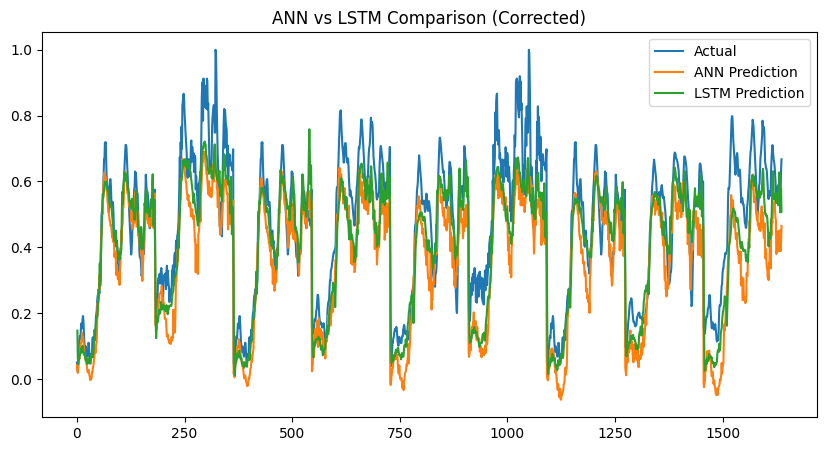

In [16]:
plt.figure(figsize=(10,5))

plt.plot(y_test.flatten(), label='Actual')
plt.plot(ann_pred.flatten(), label='ANN Prediction')

# Align LSTM properly
lstm_plot = np.empty_like(y_test.flatten())
lstm_plot[:] = np.nan
lstm_plot[-len(lstm_pred):] = lstm_pred.flatten()

plt.plot(lstm_plot, label='LSTM Prediction')

plt.legend()
plt.title("ANN vs LSTM Comparison (Corrected)")
plt.show()

### ANN shows less accurate predictions as it cannot capture temporal dependencies. LSTM performs better by learning patterns from past sequences, resulting in predictions closer to actual values.

In [17]:
from sklearn.metrics import mean_absolute_error

print("ANN MSE:", mean_squared_error(y_test, ann_pred))
print("LSTM MSE:", mean_squared_error(y_test_lstm, lstm_pred))

print("ANN MAE:", mean_absolute_error(y_test, ann_pred))
print("LSTM MAE:", mean_absolute_error(y_test_lstm, lstm_pred))

ANN MSE: 0.01761309616909713
LSTM MSE: 0.010956985339117636
ANN MAE: 0.11207167104789276
LSTM MAE: 0.08437769871787054
